# Importing Dependences

In [7]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import classification_report
import plotly.graph_objects as go
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import joblib

# Loading Data

In [2]:
df = pd.read_csv("data.csv")
#list_fn = [filename for filename in df["filename"].unique() if len(df["type"].loc[(df["filename"] == filename)].unique()) > 1]
#print(len(list_fn))

In [6]:
df = pd.read_csv("data.csv")
df_temp = df.loc[(df["type"] == "right_hand") &
                 (~df["sign"].isin(["J", "Z"]))].copy()

for sign in df_temp["sign"].unique():
    print(sign, len(df_temp["filename"].loc[(df_temp["sign"] == sign)].unique()))

data = []
y = []
for filename in df_temp["filename"].unique():
    data.append(df_temp[["x", "y", "z"]].loc[(df_temp["filename"] == filename)].values)
    y.append(df_temp["sign"].loc[(df_temp["filename"] == filename)].values[0])
    
data = np.array(data)
data = data.reshape(data.shape[0], data.shape[1]*data.shape[2])
y = np.array(y)

A 535
B 540
C 260
D 324
E 506
F 442
G 553
H 789
I 472
K 463
L 237
M 149
N 203
O 353
P 856
Q 540
R 724
S 435
T 215
U 878
V 943
W 363
X 373
Y 402


In [ ]:
sc = StandardScaler()
data = sc.fit_transform(data) 

lda = LDA(n_components=2)
components = lda.fit_transform(data, y)

fig = px.scatter(components, x=0, y=1, color=y)
fig.show()

# Visualization

In [ ]:
def visualize_3d(filename, type="right_hand"):
    df_temp = df.loc[(df["filename"] == filename) &
                     (df["type"] == type)]
    print(filename)
    df_temp = df_temp[["sign", "type", "landmark_index", "x", "y", "z"]].groupby(["sign", "type", "landmark_index"]).mean().reset_index()

    i_list = [[tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 0)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 1)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 2)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 3)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 0)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 5)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 6)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 7)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 9)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 10)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 11)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 13)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 14)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 15)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 0)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 17)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 18)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 19)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 3)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 5)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 9)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 13)].to_numpy()][0]] 


    j_list = [[tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 1)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 2)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 3)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 4)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 5)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 6)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 7)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 8)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 10)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 11)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 12)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 14)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 15)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 16)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 17)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 18)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 19)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 20)].to_numpy()][0],
            
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 5)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 9)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 13)].to_numpy()][0],
            [tuple(x) for x in df_temp[["x", "y", "z"]].loc[(df_temp["landmark_index"] == 17)].to_numpy()][0]]

    fig = go.Figure()
    for start, end in zip(i_list, j_list):
        fig.add_trace(go.Scatter3d(
            x=[start[0], end[0]], 
            y=[start[1], end[1]], 
            z=[start[2], end[2]],
            mode='lines'
        ))

    fig.show()

# Modelling

In [8]:
ohe = OneHotEncoder(sparse_output=False)
ros = RandomOverSampler(random_state=42)
sc = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(data.reshape(data.shape[0], -1), y.reshape(-1, 1),
                                                    stratify=y, 
                                                    test_size=0.2)


X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
y_train = ohe.fit_transform(y_train)
y_test = ohe.transform(y_test)

X_train, y_train = ros.fit_resample(X_train, y_train)

joblib.dump(ohe, "ohe.gz")
joblib.dump(sc, "sc.gz")

['sc.gz']

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hand_input          │ (None, 63)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 63)        │        127 │ hand_input[0][0]  │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_1 (Dense)     │ (None, 24)        │      1,536 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_concat        │ (None, 87)        │          0 │ hand_input[0][0], │
│ (Concatenate)       │                   │            │ layer_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 24)        │      2,112 │ layer_concat[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,775 (14.75 KB)

 Trainable params: 3,648 (14.25 KB)

 Non-trainable params: 127 (512.00 B)

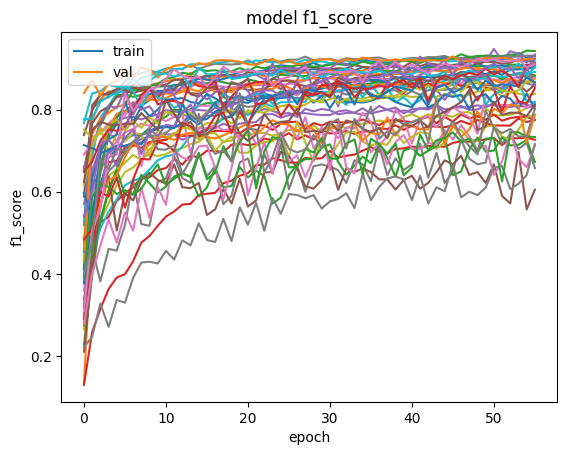

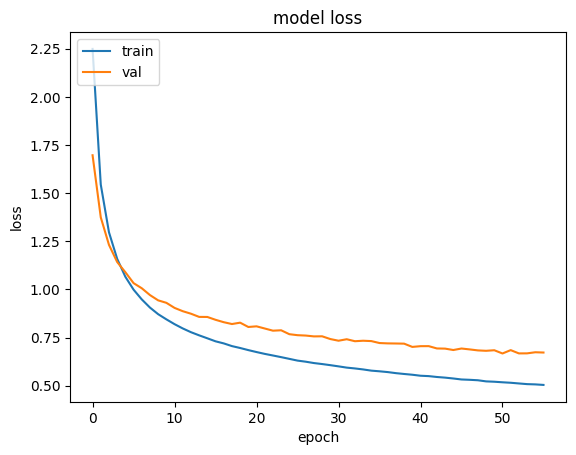

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           A       0.93      0.93      0.93       107
           B       0.89      0.83      0.86       108
           C       0.81      0.83      0.82        52
           D       0.59      0.74      0.66        65
           E       0.80      0.77      0.79       101
           F       0.78      0.86      0.82        88
           G       0.78      0.82      0.80       111
           H       0.97      0.88      0.92       158
           I       0.59      0.79      0.67        94
           K       0.90      0.81      0.85        93
           L       0.82      0.89      0.86        47
           M       0.50      0.77      0.61        30
           N       0.67      0.76      0.71        41
           O       0.69      0.75      0.72        71
           P       0.94      0.80      0.87       171
           Q       0.94      0.87      0.90       108
           R       0.94      0.81      0.8

['model.gz']

In [9]:
import joblib
import matplotlib.pyplot as plt

num_classes = len(np.unique(y))

input_A = tf.keras.layers.Input(shape=(63,), name="hand_input")
layer_1 = tf.keras.layers.Normalization(axis=-1, name="normalization")(input_A) 
layer_2 = tf.keras.layers.Dense(num_classes, activation="relu", name="layer_1")(layer_1)
concat = tf.keras.layers.concatenate([input_A, layer_2], name="layer_concat")
output = tf.keras.layers.Dense(num_classes, activation='softmax', name="output")(concat)

model = tf.keras.Model(inputs=[input_A], outputs=[output])

model.summary()
#tf.keras.utils.plot_model(model, to_file="img.png", show_shapes=True)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=[tf.keras.metrics.F1Score()])
callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                            patience=5)
result = model.fit(X_train, y_train,
                   validation_data = (X_test, y_test),
                   batch_size=32, epochs=100,
                   callbacks=[callback],
                   verbose=0)

plt.plot(result.history['f1_score'])
plt.plot(result.history['val_f1_score'])
plt.title('model f1_score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(result.history['loss'])
plt.plot(result.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

y_true = ohe.inverse_transform(y_test).reshape(-1)
y_pred = ohe.inverse_transform(model.predict(X_test)).reshape(-1)
print(classification_report(y_true, y_pred, target_names=ohe.categories_[0]))

joblib.dump(model, "model.gz")